# Kirkland Si[111] Convergent-Probe CBED

Recreate the Kirkland Fig. 7.20 Si[111] convergent-beam electron diffraction setup at 100 keV and compare WPM, angular-spectrum multislice, and Fresnel multislice.

Default parameters target the full 190 mrad scattering-angle comparison and cache compact results in `notebooks/cbed/results/cbed_kirkland_si111_100kev.npz`. Set `DEBUG_MODE = True` for a short smoke-test run.


In [28]:
%matplotlib inline

import os
import sys
from pathlib import Path
from time import perf_counter

# Set these before importing abTEM/CuPy/JAX in a fresh kernel.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", ".70")


def resolve_repo_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "notebooks").exists() and (base / "wide_angle_propagation").exists():
            return base
    return cwd


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import abtem
import ase.io
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from wide_angle_propagation.propagation_methods import (
    Propagator,
    angular_spectrum_propagation_kernel,
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    wpm_step_adaptive,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

print(f"Repository root: {REPO_ROOT}")
print(f"CUDA_VISIBLE_DEVICES = {os.environ.get('CUDA_VISIBLE_DEVICES')}")


Repository root: /home/dl277493/Documents/Code/WideAnglePropagation
CUDA_VISIBLE_DEVICES = 0


## Experiment setup

The full run uses Kirkland Fig. 7.20 optics: 100 keV, 8 mrad objective aperture, Cs = 3.3 mm, and Scherzer defocus. Thicknesses are represented by the nearest integer number of repeated Si[111] unit cells.


In [29]:
# --- Runtime controls -------------------------------------------------------
DEBUG_MODE = False
LOAD_EXISTING_RESULTS = False
RECOMPUTE_SIMULATION = True
SAVE_RESULTS_NPZ = True
SAVE_FIGURES = True

RESULTS_FILENAME = "cbed_kirkland_si111_100kev.npz"
PATTERN_FIGURE_BASENAME = "cbed_kirkland_si111_patterns"
RADIAL_FIGURE_BASENAME = "cbed_kirkland_si111_radial_profiles"

# --- Kirkland Fig. 7.20 parameters -----------------------------------------
energy = 100e3
TARGET_THICKNESSES_A = np.array([198.0, 273.0, 489.0, 1270.0], dtype=float)
PROBE_SEMIANGLE_MRAD = 8.0
CS_MM = 3.3
MAX_SCATTERING_ANGLE_MRAD = 190.0

# --- Numerical controls -----------------------------------------------------
# 0.075 A sampling gives a Nyquist angle comfortably above 190 mrad at 100 keV.
POTENTIAL_SAMPLING_A = 0.075
SLICES_PER_CELL = 32
WPM_N_BINS = 16
WPM_POWER_SPACING = 2.0
RADIAL_BIN_WIDTH_MRAD = 1.0
CBED_LOG_VMIN = 1e-8

# The archived Si notebook used this lateral Si[111] supercell for Kirkland-like CBED.
FULL_LATERAL_REPEATS = (12, 7)
DEBUG_LATERAL_REPEATS = (4, 3)
DEBUG_TARGET_THICKNESSES_A = np.array([20.0, 40.0], dtype=float)

if DEBUG_MODE:
    lateral_repeats = DEBUG_LATERAL_REPEATS
    target_thicknesses_A = DEBUG_TARGET_THICKNESSES_A.copy()
else:
    lateral_repeats = FULL_LATERAL_REPEATS
    target_thicknesses_A = TARGET_THICKNESSES_A.copy()

wavelength = float(energy2wavelength(energy))
cs_A = CS_MM * 1.0e7
scherzer_defocus_A = -1.2 * np.sqrt(cs_A * wavelength)

results_dir = REPO_ROOT / "notebooks" / "cbed" / "results"
results_path = results_dir / RESULTS_FILENAME
figures_dir = results_dir

print(f"Mode: {'debug' if DEBUG_MODE else 'full'}")
print(f"Energy: {energy / 1e3:.0f} keV, wavelength = {wavelength:.5f} A")
print(f"Probe aperture semi-angle: {PROBE_SEMIANGLE_MRAD:.1f} mrad")
print(f"Cs: {CS_MM:.2f} mm = {cs_A:.3e} A")
print(f"Scherzer defocus: {scherzer_defocus_A:.1f} A ({scherzer_defocus_A / 10:.1f} nm)")
print(f"Target thicknesses: {target_thicknesses_A} A")
print(f"Lateral repeats: {lateral_repeats[0]} x {lateral_repeats[1]}")
print(f"Result cache: {results_path}")


Mode: full
Energy: 100 keV, wavelength = 0.03701 A
Probe aperture semi-angle: 8.0 mrad
Cs: 3.30 mm = 3.300e+07 A
Scherzer defocus: -1326.2 A (-132.6 nm)
Target thicknesses: [ 198.  273.  489. 1270.] A
Lateral repeats: 12 x 7
Result cache: /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_100kev.npz


## Crystal setup

Construct a Si[111] orthogonal unit cell from `notebooks/data/Si.cif` using the same rotation recipe as the archived Si CBED notebook.


In [30]:
si_cif_path = REPO_ROOT / "notebooks" / "data" / "Si.cif"
if not si_cif_path.exists():
    raise FileNotFoundError(f"Missing Si CIF file: {si_cif_path}")

silicon = ase.io.read(si_cif_path)
silicon_111 = silicon.copy()
silicon_111.rotate((0, 0, 1), (1, 1, 1), rotate_cell=True)
silicon_111.rotate(45, "z", rotate_cell=True)
unit_cell = abtem.orthogonalize_cell(silicon_111)
unit_cell.pbc = [True, True, True]
unit_cell.wrap()

nx_rep, ny_rep = lateral_repeats
unit_supercell = unit_cell * (nx_rep, ny_rep, 1)
unit_supercell.pbc = [True, True, True]

cell_lengths_A = np.array(unit_cell.cell.lengths(), dtype=float)
cell_thickness_A = float(unit_cell.cell[2, 2])
dz_test_A = cell_thickness_A / SLICES_PER_CELL
cell_repeats = np.maximum(1, np.rint(target_thicknesses_A / cell_thickness_A).astype(int))
actual_thicknesses_A = cell_repeats * cell_thickness_A
max_cell_repeats = int(cell_repeats.max())

print(f"Orthogonal Si[111] unit cell lengths: {cell_lengths_A} A")
print(f"Si[111] repeat thickness: {cell_thickness_A:.4f} A")
print(f"Slices per repeat: {SLICES_PER_CELL}, dz = {dz_test_A:.4f} A")
print("Thickness mapping:")
for target, repeat, actual in zip(target_thicknesses_A, cell_repeats, actual_thicknesses_A):
    print(f"  target {target:7.1f} A -> {repeat:4d} repeats -> actual {actual:8.2f} A")
print(f"One-cell lateral supercell atoms: {len(unit_supercell)}")
print(f"One-cell lateral field of view: {unit_supercell.cell.lengths()[0]:.2f} x {unit_supercell.cell.lengths()[1]:.2f} A")


Orthogonal Si[111] unit cell lengths: [ 7.69855772 13.33429312  9.42876909] A
Si[111] repeat thickness: 9.4288 A
Slices per repeat: 32, dz = 0.2946 A
Thickness mapping:
  target   198.0 A ->   21 repeats -> actual   198.00 A
  target   273.0 A ->   29 repeats -> actual   273.43 A
  target   489.0 A ->   52 repeats -> actual   490.30 A
  target  1270.0 A ->  135 repeats -> actual  1272.88 A
One-cell lateral supercell atoms: 4032
One-cell lateral field of view: 92.38 x 93.34 A


## Simulation helpers

These helpers avoid storing every per-slice wavefront during the thick-specimen run. Only the exit wave after each repeated Si[111] unit cell is retained, and CBED patterns are recorded at the requested thicknesses.


In [31]:
METHOD_NAMES = ["WPM", "Angular Spectrum", "Fresnel MS"]
METHOD_LABELS = {
    "WPM": "WPM",
    "Angular Spectrum": "AS-MS",
    "Fresnel MS": "F-MS",
}
METHOD_COLORS = {
    "WPM": "C2",
    "Angular Spectrum": "C1",
    "Fresnel MS": "C0",
}
METHOD_LINESTYLES = {
    "WPM": "-",
    "Angular Spectrum": "--",
    "Fresnel MS": ":",
}


def method_key(method_name):
    return method_name.lower().replace(" ", "_").replace("-", "_")


def assert_scattering_support(sampling_A, wavelength_A, max_angle_mrad):
    max_sampling_A = max(float(sampling_A[0]), float(sampling_A[1]))
    nyquist_mrad = 1e3 * np.arcsin(np.clip(wavelength_A / (2.0 * max_sampling_A), 0.0, 1.0))
    print(f"Grid sampling: ({sampling_A[0]:.5f}, {sampling_A[1]:.5f}) A")
    print(f"Nyquist scattering angle: {nyquist_mrad:.1f} mrad")
    if nyquist_mrad < max_angle_mrad:
        raise ValueError(
            f"Grid only supports {nyquist_mrad:.1f} mrad, below requested "
            f"{max_angle_mrad:.1f} mrad. Reduce POTENTIAL_SAMPLING_A."
        )
    return nyquist_mrad


def build_one_cell_potential_and_kernels():
    print("Building one-cell Si[111] potential...")
    potential_abtem = abtem.Potential(
        unit_supercell,
        sampling=POTENTIAL_SAMPLING_A,
        slice_thickness=dz_test_A,
        projection="finite",
        parametrization="lobato",
    )
    gpts_local = tuple(int(v) for v in potential_abtem.gpts)
    sampling_local = tuple(float(v) for v in potential_abtem.sampling)
    built = cupy.asnumpy(potential_abtem.build(lazy=False).array)
    pot_cell_local = jnp.array(built / dz_test_A, dtype=jnp.float64)
    del potential_abtem, built
    cupy.get_default_memory_pool().free_all_blocks()

    if pot_cell_local.shape[0] != SLICES_PER_CELL:
        print(
            "Warning: built potential has "
            f"{pot_cell_local.shape[0]} slices, expected {SLICES_PER_CELL}. "
            "Using the configured dz for propagation."
        )

    fk_local = jnp.array(
        fresnel_propagation_kernel(*gpts_local, sampling_local, z=dz_test_A, energy=energy)
    )
    ak_local = jnp.array(
        angular_spectrum_propagation_kernel(*gpts_local, sampling_local, z=dz_test_A, energy=energy)
    )
    print(f"Potential shape: {pot_cell_local.shape}")
    print(f"Grid: {gpts_local}")
    assert_scattering_support(sampling_local, wavelength, MAX_SCATTERING_ANGLE_MRAD)
    return pot_cell_local, fk_local, ak_local, gpts_local, sampling_local


def make_kirkland_probe(ny, nx, sampling_A, wavelength_A, semiangle_mrad, defocus_A, cs_A):
    samp_y, samp_x = sampling_A
    fy = np.fft.fftfreq(ny, d=samp_y)
    fx = np.fft.fftfreq(nx, d=samp_x)
    fx_grid, fy_grid = np.meshgrid(fx, fy)
    spatial_frequency = np.sqrt(fx_grid**2 + fy_grid**2)
    alpha = np.arcsin(np.clip(wavelength_A * spatial_frequency, 0.0, 1.0))

    aperture = alpha <= semiangle_mrad * 1e-3
    if not np.any(aperture):
        raise ValueError(f"No aperture pixels for {semiangle_mrad} mrad probe")

    aberration_length_A = 0.5 * defocus_A * alpha**2 + 0.25 * cs_A * alpha**4
    aberration_phase = np.exp(-1j * (2.0 * np.pi / wavelength_A) * aberration_length_A)
    probe_fft = aperture.astype(np.complex128) * aberration_phase
    probe_fft /= np.linalg.norm(probe_fft)

    # The FFT grid is unshifted; fftshift centers the real-space probe in the array.
    probe = np.fft.fftshift(np.fft.ifft2(probe_fft))
    return jnp.array(probe, dtype=jnp.complex128)


def simulate_fresnel_as_exit_only(potential, wave, propagation_kernel, slice_thickness_A, energy_eV):
    wavelength_A = energy2wavelength(energy_eV)
    wavefront = wave
    for i in range(potential.shape[0]):
        n_map = electron_refractive_index(potential[i], energy_eV)
        phase_shift = jnp.exp(1j * 2.0 * jnp.pi * (n_map - 1.0) * slice_thickness_A / wavelength_A)
        wavefront = Propagator(wavefront * phase_shift, propagation_kernel)
    return wavefront


def simulate_wpm_exit_only(
    potential,
    wave,
    slice_thickness_A,
    energy_eV,
    sampling_A,
    n_bins=WPM_N_BINS,
    power_spacing=WPM_POWER_SPACING,
):
    wavefront = wave
    for i in range(potential.shape[0]):
        n_map = electron_refractive_index(potential[i], energy_eV)
        wavefront, _, _, _ = wpm_step_adaptive(
            wavefront,
            n_map,
            slice_thickness_A,
            energy_eV,
            sampling_A,
            n_bins=n_bins,
            power_spacing=power_spacing,
        )
    return wavefront


def block_until_ready(value):
    return jax.block_until_ready(value)


def diffraction_pattern(exit_wave):
    wave = np.asarray(exit_wave)
    return np.abs(np.fft.fftshift(np.fft.fft2(wave))) ** 2


def diffraction_angle_axes_mrad(ny, nx, sampling_A, wavelength_A):
    samp_y, samp_x = sampling_A
    fy = np.fft.fftshift(np.fft.fftfreq(ny, d=samp_y))
    fx = np.fft.fftshift(np.fft.fftfreq(nx, d=samp_x))
    theta_y = 1e3 * np.arcsin(np.clip(wavelength_A * fy, -1.0, 1.0))
    theta_x = 1e3 * np.arcsin(np.clip(wavelength_A * fx, -1.0, 1.0))
    return theta_y, theta_x


def angle_crop_slices(theta_y, theta_x, cutoff_mrad):
    y_idx = np.where(np.abs(theta_y) <= cutoff_mrad)[0]
    x_idx = np.where(np.abs(theta_x) <= cutoff_mrad)[0]
    if y_idx.size == 0 or x_idx.size == 0:
        raise ValueError(f"No pixels inside +/- {cutoff_mrad} mrad crop")
    return slice(y_idx[0], y_idx[-1] + 1), slice(x_idx[0], x_idx[-1] + 1)


def radial_integrated_profiles(patterns_by_method, theta_y, theta_x, max_angle_mrad, bin_width_mrad):
    theta_x_grid, theta_y_grid = np.meshgrid(theta_x, theta_y)
    radius = np.sqrt(theta_x_grid**2 + theta_y_grid**2)
    valid = radius <= max_angle_mrad
    bin_edges = np.arange(0.0, max_angle_mrad + bin_width_mrad, bin_width_mrad)
    if bin_edges[-1] < max_angle_mrad:
        bin_edges = np.append(bin_edges, max_angle_mrad)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    radial_sums = {}
    radial_profiles = {}
    for method, stack in patterns_by_method.items():
        method_sums = []
        method_profiles = []
        for pattern in stack:
            annular_sum, _ = np.histogram(radius[valid], bins=bin_edges, weights=np.asarray(pattern)[valid])
            annular_sum = annular_sum.astype(np.float64)
            total = float(annular_sum.sum())
            profile = annular_sum / total if total > 0.0 else annular_sum
            method_sums.append(annular_sum)
            method_profiles.append(profile)
        radial_sums[method] = np.stack(method_sums)
        radial_profiles[method] = np.stack(method_profiles)
    return bin_edges, bin_centers, radial_sums, radial_profiles


def metadata_dict(gpts, sampling_A, nyquist_mrad):
    return {
        "description": "Kirkland Fig. 7.20 Si[111] CBED comparison with static crystal",
        "energy_eV": float(energy),
        "wavelength_A": float(wavelength),
        "probe_semiangle_mrad": float(PROBE_SEMIANGLE_MRAD),
        "Cs_mm": float(CS_MM),
        "Cs_A": float(cs_A),
        "defocus_A": float(scherzer_defocus_A),
        "max_scattering_angle_mrad": float(MAX_SCATTERING_ANGLE_MRAD),
        "potential_sampling_requested_A": float(POTENTIAL_SAMPLING_A),
        "sampling_A": tuple(float(v) for v in sampling_A),
        "gpts": tuple(int(v) for v in gpts),
        "nyquist_angle_mrad": float(nyquist_mrad),
        "slices_per_cell": int(SLICES_PER_CELL),
        "dz_A": float(dz_test_A),
        "cell_thickness_A": float(cell_thickness_A),
        "lateral_repeats": tuple(int(v) for v in lateral_repeats),
        "target_thicknesses_A": tuple(float(v) for v in target_thicknesses_A),
        "actual_thicknesses_A": tuple(float(v) for v in actual_thicknesses_A),
        "cell_repeats": tuple(int(v) for v in cell_repeats),
        "radial_bin_width_mrad": float(RADIAL_BIN_WIDTH_MRAD),
        "static_crystal": True,
        "debug_mode": bool(DEBUG_MODE),
    }


def save_results(path, cbed_results):
    arrays = {
        "method_names": np.array(cbed_results["method_names"], dtype=object),
        "target_thicknesses_A": np.asarray(cbed_results["target_thicknesses_A"], dtype=float),
        "actual_thicknesses_A": np.asarray(cbed_results["actual_thicknesses_A"], dtype=float),
        "cell_repeats": np.asarray(cbed_results["cell_repeats"], dtype=int),
        "gpts": np.asarray(cbed_results["gpts"], dtype=int),
        "sampling_A": np.asarray(cbed_results["sampling_A"], dtype=float),
        "theta_y_mrad": np.asarray(cbed_results["theta_y_mrad"], dtype=float),
        "theta_x_mrad": np.asarray(cbed_results["theta_x_mrad"], dtype=float),
        "radial_bin_edges_mrad": np.asarray(cbed_results["radial_bin_edges_mrad"], dtype=float),
        "radial_bin_centers_mrad": np.asarray(cbed_results["radial_bin_centers_mrad"], dtype=float),
        "metadata": np.array([cbed_results["metadata"]], dtype=object),
    }
    for method in cbed_results["method_names"]:
        key = method_key(method)
        arrays[f"{key}_patterns"] = np.asarray(cbed_results["patterns"][method], dtype=np.float32)
        arrays[f"{key}_radial_sums"] = np.asarray(cbed_results["radial_sums"][method], dtype=np.float64)
        arrays[f"{key}_radial_profiles"] = np.asarray(cbed_results["radial_profiles"][method], dtype=np.float64)
        arrays[f"{key}_runtime_at_targets_s"] = np.asarray(cbed_results["runtime_at_targets_s"][method], dtype=float)
        arrays[f"{key}_cell_runtime_s"] = np.asarray(cbed_results["cell_runtime_s"][method], dtype=float)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **arrays)
    print(f"Saved compact results -> {path}")


def load_results(path):
    with np.load(path, allow_pickle=True) as data:
        loaded_methods = [str(v) for v in data["method_names"]]
        loaded = {
            "method_names": loaded_methods,
            "target_thicknesses_A": data["target_thicknesses_A"].astype(float),
            "actual_thicknesses_A": data["actual_thicknesses_A"].astype(float),
            "cell_repeats": data["cell_repeats"].astype(int),
            "gpts": tuple(int(v) for v in data["gpts"]),
            "sampling_A": tuple(float(v) for v in data["sampling_A"]),
            "theta_y_mrad": data["theta_y_mrad"].astype(float),
            "theta_x_mrad": data["theta_x_mrad"].astype(float),
            "radial_bin_edges_mrad": data["radial_bin_edges_mrad"].astype(float),
            "radial_bin_centers_mrad": data["radial_bin_centers_mrad"].astype(float),
            "metadata": dict(data["metadata"][0]),
            "patterns": {},
            "radial_sums": {},
            "radial_profiles": {},
            "runtime_at_targets_s": {},
            "cell_runtime_s": {},
        }
        for method in loaded_methods:
            key = method_key(method)
            loaded["patterns"][method] = data[f"{key}_patterns"].copy()
            loaded["radial_sums"][method] = data[f"{key}_radial_sums"].copy()
            loaded["radial_profiles"][method] = data[f"{key}_radial_profiles"].copy()
            loaded["runtime_at_targets_s"][method] = data[f"{key}_runtime_at_targets_s"].copy()
            loaded["cell_runtime_s"][method] = data[f"{key}_cell_runtime_s"].copy()
    print(f"Loaded compact results -> {path}")
    return loaded


## Load or run CBED series

The simulation propagates all three methods through repeated one-cell Si[111] potentials and records CBED patterns at the requested thicknesses.


In [32]:
should_load = LOAD_EXISTING_RESULTS and results_path.exists() and not RECOMPUTE_SIMULATION

if should_load:
    cbed_results = load_results(results_path)
    gpts = tuple(cbed_results["gpts"])
    sampling = tuple(cbed_results["sampling_A"])
    theta_y_mrad = cbed_results["theta_y_mrad"]
    theta_x_mrad = cbed_results["theta_x_mrad"]
    assert_scattering_support(sampling, wavelength, MAX_SCATTERING_ANGLE_MRAD)
else:
    pot_cell, fk, ak, gpts, sampling = build_one_cell_potential_and_kernels()
    ny_g, nx_g = gpts
    theta_y_mrad, theta_x_mrad = diffraction_angle_axes_mrad(ny_g, nx_g, sampling, wavelength)

    probe = make_kirkland_probe(
        ny_g,
        nx_g,
        sampling,
        wavelength,
        PROBE_SEMIANGLE_MRAD,
        scherzer_defocus_A,
        cs_A,
    )
    block_until_ready(probe)

    waves = {method: probe for method in METHOD_NAMES}
    patterns = {
        method: np.empty((len(cell_repeats), ny_g, nx_g), dtype=np.float32)
        for method in METHOD_NAMES
    }
    cell_runtime_s = {
        method: np.zeros(max_cell_repeats, dtype=float)
        for method in METHOD_NAMES
    }
    runtime_at_targets_s = {
        method: np.zeros(len(cell_repeats), dtype=float)
        for method in METHOD_NAMES
    }
    cumulative_runtime_s = {method: 0.0 for method in METHOD_NAMES}
    repeat_to_target_indices = {}
    for idx, repeat in enumerate(cell_repeats):
        repeat_to_target_indices.setdefault(int(repeat), []).append(idx)

    print(f"Propagating {max_cell_repeats} Si[111] repeats through {METHOD_NAMES}...")
    for cell_idx in range(1, max_cell_repeats + 1):
        if cell_idx == 1 or cell_idx in repeat_to_target_indices or cell_idx % 10 == 0 or cell_idx == max_cell_repeats:
            print(f"  repeat {cell_idx:4d}/{max_cell_repeats} ({cell_idx * cell_thickness_A:8.2f} A)")

        for method in METHOD_NAMES:
            t0 = perf_counter()
            if method == "WPM":
                waves[method] = simulate_wpm_exit_only(
                    pot_cell,
                    waves[method],
                    dz_test_A,
                    energy,
                    sampling,
                    n_bins=WPM_N_BINS,
                    power_spacing=WPM_POWER_SPACING,
                )
            elif method == "Angular Spectrum":
                waves[method] = simulate_fresnel_as_exit_only(pot_cell, waves[method], ak, dz_test_A, energy)
            elif method == "Fresnel MS":
                waves[method] = simulate_fresnel_as_exit_only(pot_cell, waves[method], fk, dz_test_A, energy)
            else:
                raise KeyError(method)
            block_until_ready(waves[method])
            elapsed = perf_counter() - t0
            cell_runtime_s[method][cell_idx - 1] = elapsed
            cumulative_runtime_s[method] += elapsed

        if cell_idx in repeat_to_target_indices:
            for target_idx in repeat_to_target_indices[cell_idx]:
                for method in METHOD_NAMES:
                    patterns[method][target_idx] = diffraction_pattern(waves[method]).astype(np.float32)
                    runtime_at_targets_s[method][target_idx] = cumulative_runtime_s[method]

    radial_bin_edges_mrad, radial_bin_centers_mrad, radial_sums, radial_profiles = radial_integrated_profiles(
        patterns,
        theta_y_mrad,
        theta_x_mrad,
        MAX_SCATTERING_ANGLE_MRAD,
        RADIAL_BIN_WIDTH_MRAD,
    )
    nyquist_mrad = assert_scattering_support(sampling, wavelength, MAX_SCATTERING_ANGLE_MRAD)

    cbed_results = {
        "method_names": METHOD_NAMES,
        "target_thicknesses_A": target_thicknesses_A.copy(),
        "actual_thicknesses_A": actual_thicknesses_A.copy(),
        "cell_repeats": cell_repeats.copy(),
        "gpts": gpts,
        "sampling_A": sampling,
        "theta_y_mrad": theta_y_mrad,
        "theta_x_mrad": theta_x_mrad,
        "radial_bin_edges_mrad": radial_bin_edges_mrad,
        "radial_bin_centers_mrad": radial_bin_centers_mrad,
        "patterns": patterns,
        "radial_sums": radial_sums,
        "radial_profiles": radial_profiles,
        "runtime_at_targets_s": runtime_at_targets_s,
        "cell_runtime_s": cell_runtime_s,
        "metadata": metadata_dict(gpts, sampling, nyquist_mrad),
    }

    if SAVE_RESULTS_NPZ:
        save_results(results_path, cbed_results)

    del pot_cell, fk, ak, waves
    cupy.get_default_memory_pool().free_all_blocks()

print("Available result thicknesses:")
for target, repeat, actual in zip(
    cbed_results["target_thicknesses_A"],
    cbed_results["cell_repeats"],
    cbed_results["actual_thicknesses_A"],
):
    print(f"  target {target:7.1f} A -> {repeat:4d} repeats -> actual {actual:8.2f} A")

print("Timing at final recorded thickness:")
for method in cbed_results["method_names"]:
    print(f"  {METHOD_LABELS.get(method, method):<8s} {cbed_results['runtime_at_targets_s'][method][-1]:10.2f} s")


Building one-cell Si[111] potential...
Potential shape: (32, 1232, 1245)
Grid: (1232, 1245)
Grid sampling: (0.07499, 0.07497) A
Nyquist scattering angle: 249.4 mrad
Propagating 135 Si[111] repeats through ['WPM', 'Angular Spectrum', 'Fresnel MS']...
  repeat    1/135 (    9.43 A)
  repeat   10/135 (   94.29 A)
  repeat   20/135 (  188.58 A)
  repeat   21/135 (  198.00 A)
  repeat   29/135 (  273.43 A)
  repeat   30/135 (  282.86 A)
  repeat   40/135 (  377.15 A)
  repeat   50/135 (  471.44 A)
  repeat   52/135 (  490.30 A)
  repeat   60/135 (  565.73 A)
  repeat   70/135 (  660.01 A)
  repeat   80/135 (  754.30 A)
  repeat   90/135 (  848.59 A)
  repeat  100/135 (  942.88 A)
  repeat  110/135 ( 1037.16 A)
  repeat  120/135 ( 1131.45 A)
  repeat  130/135 ( 1225.74 A)
  repeat  135/135 ( 1272.88 A)
Grid sampling: (0.07499, 0.07497) A
Nyquist scattering angle: 249.4 mrad
Saved compact results -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_

## Validate cached arrays

This is a lightweight check that the stored CBED patterns and radial profiles are finite and have the expected method/thickness dimensions.


In [33]:
def validate_cbed_results(results):
    n_thicknesses = len(results["actual_thicknesses_A"])
    for method in results["method_names"]:
        pattern_stack = results["patterns"][method]
        radial_stack = results["radial_profiles"][method]
        if pattern_stack.shape[0] != n_thicknesses:
            raise ValueError(f"{method}: expected {n_thicknesses} patterns, got {pattern_stack.shape[0]}")
        if radial_stack.shape[0] != n_thicknesses:
            raise ValueError(f"{method}: expected {n_thicknesses} radial profiles, got {radial_stack.shape[0]}")
        if not np.all(np.isfinite(pattern_stack)):
            raise ValueError(f"{method}: non-finite CBED pattern values")
        if not np.all(np.isfinite(radial_stack)):
            raise ValueError(f"{method}: non-finite radial profile values")
    print("Validation passed: finite CBED patterns and radial profiles for all methods/thicknesses.")


validate_cbed_results(cbed_results)


Validation passed: finite CBED patterns and radial profiles for all methods/thicknesses.


## CBED pattern comparison

Each row is one target thickness. Each column is one propagation method. Intensities are normalized by the global maximum over the plotted panels and displayed on a shared logarithmic scale inside the 190 mrad scattering-angle aperture.


Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_patterns.png
Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_patterns.pdf


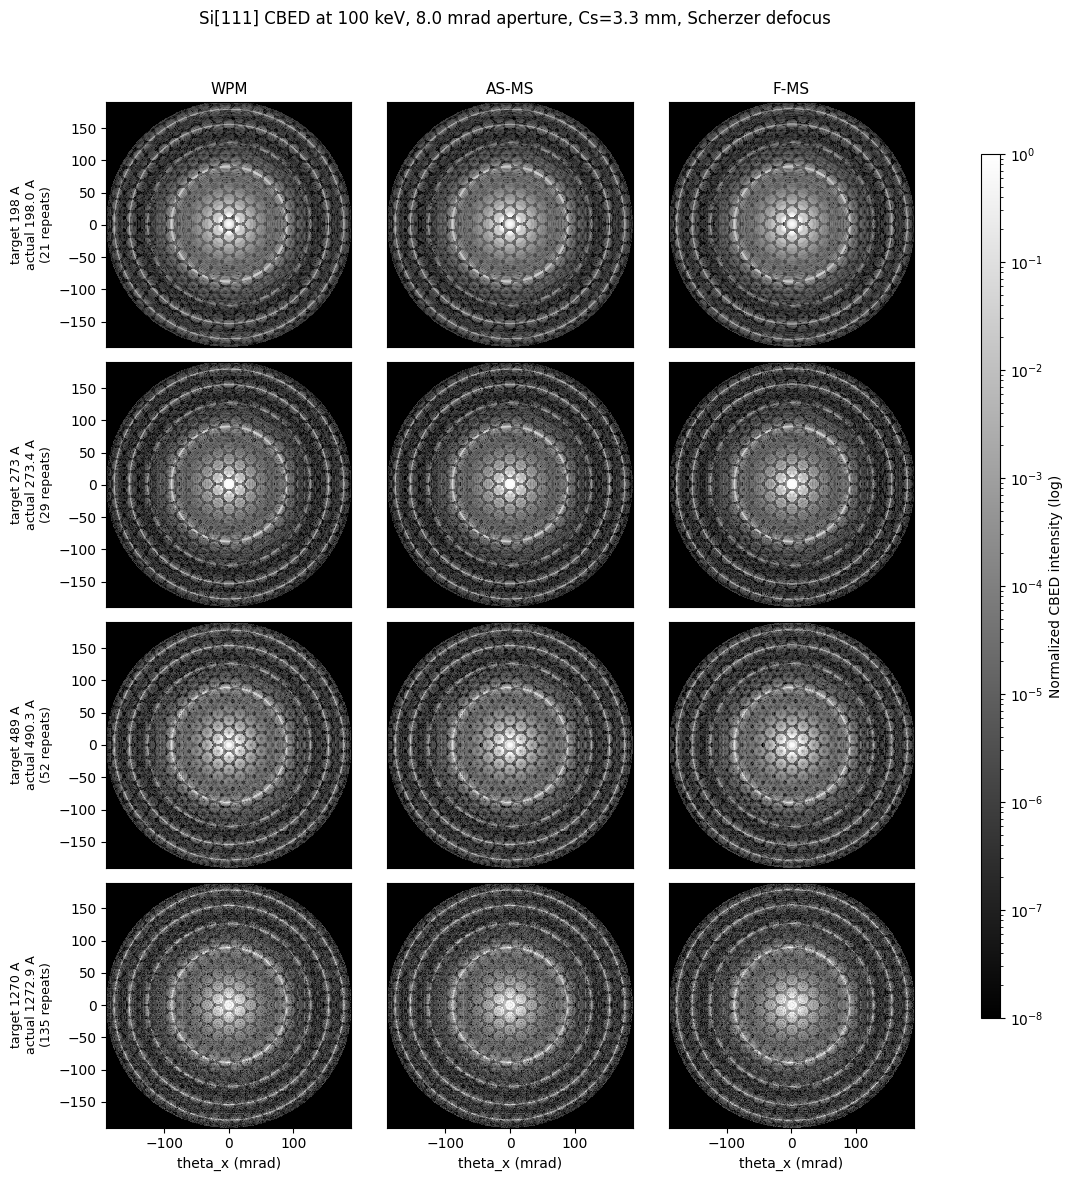

In [34]:
def masked_angle_crop(pattern, theta_y, theta_x, cutoff_mrad):
    y_slice, x_slice = angle_crop_slices(theta_y, theta_x, cutoff_mrad)
    crop = np.asarray(pattern)[y_slice, x_slice].astype(np.float64)
    tx_grid, ty_grid = np.meshgrid(theta_x[x_slice], theta_y[y_slice])
    radius = np.sqrt(tx_grid**2 + ty_grid**2)
    crop = np.where(radius <= cutoff_mrad, crop, np.nan)
    extent = [theta_x[x_slice.start], theta_x[x_slice.stop - 1], theta_y[y_slice.start], theta_y[y_slice.stop - 1]]
    return crop, extent


method_plot_order = [m for m in ["WPM", "Angular Spectrum", "Fresnel MS"] if m in cbed_results["method_names"]]
pattern_cache = {}
global_max = 0.0
for method in method_plot_order:
    pattern_cache[method] = []
    for pattern in cbed_results["patterns"][method]:
        crop, extent = masked_angle_crop(
            pattern,
            cbed_results["theta_y_mrad"],
            cbed_results["theta_x_mrad"],
            MAX_SCATTERING_ANGLE_MRAD,
        )
        pattern_cache[method].append(crop)
        finite = crop[np.isfinite(crop)]
        if finite.size:
            global_max = max(global_max, float(finite.max()))

if global_max <= 0.0:
    raise ValueError("CBED patterns have no positive intensity inside the plotting aperture")

cmap = plt.get_cmap("gray").copy()
cmap.set_bad("black")

n_rows = len(cbed_results["actual_thicknesses_A"])
n_cols = len(method_plot_order)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols + 1.0, 3.0 * n_rows), squeeze=False)
last_im = None
for row in range(n_rows):
    target_A = cbed_results["target_thicknesses_A"][row]
    actual_A = cbed_results["actual_thicknesses_A"][row]
    repeat = cbed_results["cell_repeats"][row]
    for col, method in enumerate(method_plot_order):
        ax = axes[row, col]
        display = pattern_cache[method][row] / global_max
        display = np.where(np.isfinite(display), np.maximum(display, CBED_LOG_VMIN), np.nan)
        last_im = ax.imshow(
            display,
            origin="lower",
            extent=extent,
            cmap=cmap,
            norm=LogNorm(vmin=CBED_LOG_VMIN, vmax=1.0),
            interpolation="nearest",
        )
        if row == 0:
            ax.set_title(METHOD_LABELS.get(method, method), fontsize=11)
        if col == 0:
            ax.set_ylabel(f"target {target_A:.0f} A\nactual {actual_A:.1f} A\n({repeat:d} repeats)", fontsize=9)
        else:
            ax.set_yticks([])
        if row == n_rows - 1:
            ax.set_xlabel("theta_x (mrad)")
        else:
            ax.set_xticks([])
        ax.set_aspect("equal")

fig.suptitle(
    f"Si[111] CBED at {energy / 1e3:.0f} keV, {PROBE_SEMIANGLE_MRAD:.1f} mrad aperture, "
    f"Cs={CS_MM:.1f} mm, Scherzer defocus",
    fontsize=12,
)
fig.tight_layout(rect=[0.0, 0.0, 0.92, 0.96])
cax = fig.add_axes([0.94, 0.14, 0.018, 0.72])
cbar = fig.colorbar(last_im, cax=cax)
cbar.set_label("Normalized CBED intensity (log)")

if SAVE_FIGURES:
    figures_dir.mkdir(parents=True, exist_ok=True)
    png_path = figures_dir / f"{PATTERN_FIGURE_BASENAME}.png"
    pdf_path = figures_dir / f"{PATTERN_FIGURE_BASENAME}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure -> {png_path}")
    print(f"Saved figure -> {pdf_path}")

plt.show()


## Radially integrated intensity

The radial profiles are raw annular sums inside 190 mrad, normalized by each pattern's total intensity inside that aperture. The raw annular sums are also stored in the NPZ file.


Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_radial_profiles.png
Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_kirkland_si111_radial_profiles.pdf


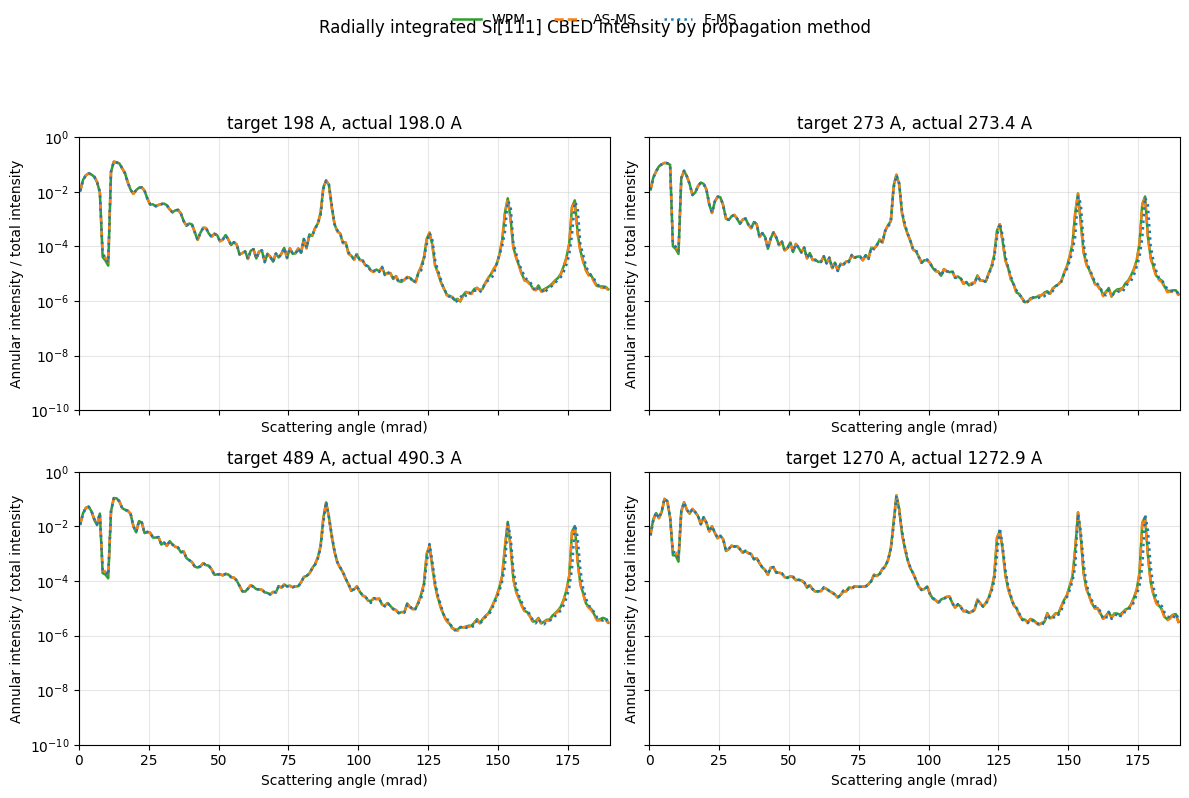

In [35]:
centers = cbed_results["radial_bin_centers_mrad"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for idx, ax in enumerate(axes):
    if idx >= len(cbed_results["actual_thicknesses_A"]):
        ax.axis("off")
        continue
    target_A = cbed_results["target_thicknesses_A"][idx]
    actual_A = cbed_results["actual_thicknesses_A"][idx]
    for method in method_plot_order:
        profile = cbed_results["radial_profiles"][method][idx]
        ax.semilogy(
            centers,
            np.maximum(profile, 1e-18),
            color=METHOD_COLORS.get(method, None),
            linestyle=METHOD_LINESTYLES.get(method, "-"),
            linewidth=1.8,
            label=METHOD_LABELS.get(method, method),
        )
    ax.set_title(f"target {target_A:.0f} A, actual {actual_A:.1f} A")
    ax.set_xlim(0.0, MAX_SCATTERING_ANGLE_MRAD)
    ax.set_ylim(1e-10, 1.0)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Scattering angle (mrad)")
    ax.set_ylabel("Annular intensity / total intensity")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False)
fig.suptitle("Radially integrated Si[111] CBED intensity by propagation method", fontsize=12)
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.92])

if SAVE_FIGURES:
    figures_dir.mkdir(parents=True, exist_ok=True)
    png_path = figures_dir / f"{RADIAL_FIGURE_BASENAME}.png"
    pdf_path = figures_dir / f"{RADIAL_FIGURE_BASENAME}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure -> {png_path}")
    print(f"Saved figure -> {pdf_path}")

plt.show()


## Timing summary

Cumulative propagation time is recorded at each saved thickness for each method.


In [36]:
print(f"{'Method':<18s} {'Target A':>10s} {'Actual A':>10s} {'Repeats':>8s} {'Runtime s':>12s}")
print("-" * 66)
for method in method_plot_order:
    for target_A, actual_A, repeat, runtime_s in zip(
        cbed_results["target_thicknesses_A"],
        cbed_results["actual_thicknesses_A"],
        cbed_results["cell_repeats"],
        cbed_results["runtime_at_targets_s"][method],
    ):
        print(
            f"{METHOD_LABELS.get(method, method):<18s} "
            f"{target_A:10.1f} {actual_A:10.1f} {int(repeat):8d} {runtime_s:12.2f}"
        )


Method               Target A   Actual A  Repeats    Runtime s
------------------------------------------------------------------
WPM                     198.0      198.0       21        19.24
WPM                     273.0      273.4       29        24.67
WPM                     489.0      490.3       52        40.36
WPM                    1270.0     1272.9      135        99.62
AS-MS                   198.0      198.0       21         2.09
AS-MS                   273.0      273.4       29         2.51
AS-MS                   489.0      490.3       52         3.85
AS-MS                  1270.0     1272.9      135         9.17
F-MS                    198.0      198.0       21         2.13
F-MS                    273.0      273.4       29         2.51
F-MS                    489.0      490.3       52         3.72
F-MS                   1270.0     1272.9      135         8.88
